In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

Mounted at /content/gdrive


## CartPole Environment 들여다 보기

https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

**Gym Env. 기본 구조**

```python
class CartPoleEnv(gym.Env[np.ndarray, Union[int, np.ndarray]]):
    def __init__(self, render_mode: Optional[str] = None):
        self.gravity = 9.8
          ....
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

    def step(self, action):
        ...
        self.state = (x, x_dot, theta, theta_dot)
        terminated = bool( ... )
        reward = ( ... )
        return np.array(self.state, dtype=np.float32), reward, terminated, {}

    def reset(self, ... ):
        return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        ...

    def close(self):
      ...

```            

In [1]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Neural Network 적용

In [2]:
import tensorflow as tf
import keras
import keras.layers as layers
from keras.models import Sequential
from keras.layers import Dense,Dropout,Input
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from collections import deque
import numpy as np
import random

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore")

# Model

### Neural Model

In [3]:
# (position,velocity,angle,angular_velocity)
input_d = env.observation_space.shape[0] # 4
output_d = env.action_space.n            # 2(left,right)

def NeuralNetwork():
    model=Sequential()
    model.add(keras.Input(shape=(input_d,)))        # input:4
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(output_d, activation='linear')) # output:2
    model.compile(loss='mse', optimizer=tf.optimizers.Adam(0.001,weight_decay=0.02))
    return model

q_network = NeuralNetwork()
q_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#keras.utils.plot_model(q_network,'model.png',show_shapes=True,show_layer_activations=True)

In [4]:
def get_action(state,epsilon): #epsilon greedy policy
    if(np.random.random() < epsilon): # exploration
        a = np.random.randint(0, env.action_space.n)
    else:                             # exploitation
        ## Q-Network에서 q값 추정
        q = q_network.predict(state, verbose=0)
        a = np.argmax(q[0])
    return a

In [7]:
## Q-network Tranining
gamma     = 0.99 # 할인율
def model_learning(s,a,r,ns,done,print_q=False):
    s = s.reshape(1,4)
    ns = ns.reshape(1,4)
    target = q_network.predict(ns, verbose=0)  #(1,2)
    if done:     # Terminal 이면 현재 reward가 Target
        target[0][a] = r    #
    else:        # Target = r+ gamma*max_aQ'(s',a')
        target[0][a] = r + gamma * np.max(target)
    if print_q :
        current = q_network.predict(s, verbose=0)  #(1,2)
        print(f"curent:{current[0]}")
        print(f"target:{target[0]}")
    history = q_network.fit(s, target, epochs=1, verbose=0)
    return history.history['loss'][0]

## Training

In [8]:
def q_net_eval(n_episode):
  mean_score = 0
  for i in range(n_episode):
      s,_ = env.reset()
      score = 0                # Eps.별 보상
      while True :                    # Termination 까지
          a = q_network.predict(s.reshape(1,4),verbose=0)
          a = np.argmax(a)
          s, r, done, _, _ = env.step(a)# step(a)
          score += r                  # episode내 reward
          if done : break
      mean_score += score/n_episode
  print(f'Evaluation score:{mean_score:.1f}')
  return mean_score

In [9]:
%%time
save_path = './model_save.keras'
env.reset()
q_network = NeuralNetwork()

n_episode = 50
eps = epsilon = 0.5 # 0.2
scores=[0]     # Eps.별 누적보상
losses=[]
max_eval_score = 20

# RL Training loop
for i in range(n_episode):
#    eps =  epsilon*(n_episode-i)/n_episode
    s, _ = env.reset()                 # s <- random
    score = loss = 0                # Eps.별 보상
    while True :                    # Termination 까지
        a = get_action(s.reshape(1,4),eps)# epsilon greedy policy
        ns, r, done, info, _ = env.step(a) # step(a)
        loss = model_learning(s,a,r,ns,done) # Training
        s = ns
        score += r                  # episode내 reward
        if done : break
    scores.append(score)
    losses.append(loss)
    mean_score = np.mean(scores[-5:])
    print(f'Eps.[{i:03d}], mean_score:{mean_score:.1f}, score:{score:.1f}, loss:{loss:.4f}, Epsilon:{eps:.4f}')
    if mean_score > max_eval_score : # model evaluation & save
        eval_score = q_net_eval(5)
        if eval_score > max_eval_score :
            max_eval_score = eval_score
            q_network.save(save_path)
            print(f"Saved model({eval_score:.1f})")
    if mean_score > 50 : break
env.close()

Eps.[000], mean_score:25.5, score:51.0, loss:0.0611, Epsilon:0.5000
Evaluation score:82.8
Saved model(82.8)
Eps.[001], mean_score:36.0, score:57.0, loss:0.8273, Epsilon:0.5000
Eps.[002], mean_score:46.0, score:76.0, loss:29.0091, Epsilon:0.5000
Eps.[003], mean_score:42.0, score:26.0, loss:72.7233, Epsilon:0.5000
Eps.[004], mean_score:49.4, score:37.0, loss:63.5065, Epsilon:0.5000
Eps.[005], mean_score:44.4, score:26.0, loss:76.1505, Epsilon:0.5000
Eps.[006], mean_score:37.8, score:24.0, loss:118.7913, Epsilon:0.5000
Eps.[007], mean_score:28.0, score:27.0, loss:124.4297, Epsilon:0.5000
Eps.[008], mean_score:29.0, score:31.0, loss:141.2576, Epsilon:0.5000
Eps.[009], mean_score:24.2, score:13.0, loss:175.1214, Epsilon:0.5000
Eps.[010], mean_score:25.4, score:32.0, loss:151.4973, Epsilon:0.5000
Eps.[011], mean_score:26.2, score:28.0, loss:194.4160, Epsilon:0.5000
Eps.[012], mean_score:27.2, score:32.0, loss:216.8068, Epsilon:0.5000
Eps.[013], mean_score:24.6, score:18.0, loss:213.6891, Eps

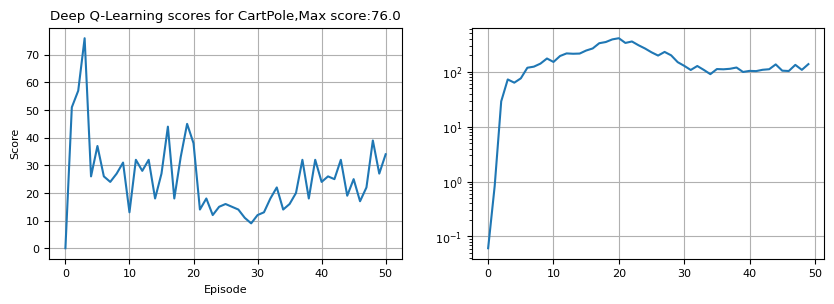

In [10]:
plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title(f"Deep Q-Learning scores for CartPole,Max score:{max(scores)}")
plt.ylabel('Score')
plt.xlabel('Episode')
plt.plot(scores)
plt.grid()

plt.subplot(122)
plt.plot(losses)
plt.semilogy()
plt.grid()
plt.show()

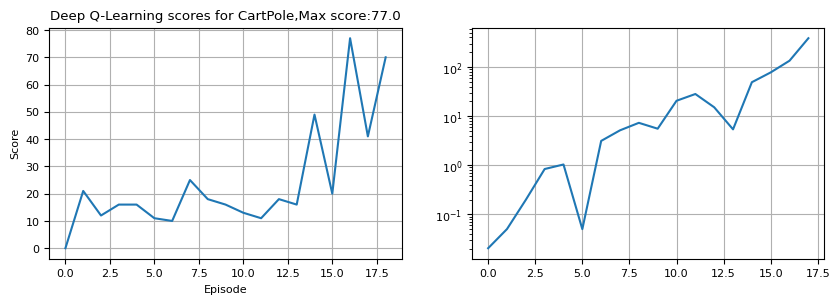

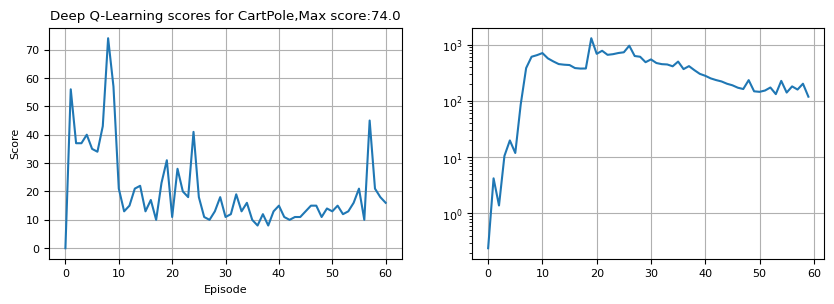

# Evaluation  

In [11]:
q_network = keras.models.load_model(save_path)

In [12]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [13]:
from render import  show_video, wrap_env, render_as_image ## library 불러오기

ModuleNotFoundError: No module named 'render'

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="q2")

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = q_network.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info, _ = env_v.step(action)
    if done or cnt > 50:  break;
    cnt += 1
# env_v.close()

In [ ]:
show_video(path=path,name_prefix='q2')

In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-1.mp4


# 실습과제  
## 100 episode에서 성능을 최대한 높여보자  
## 어떤 부분을 tuning해 볼 수 있을까?  
### epsilon?, epsilon scheduling?
### Learning rate?, learning rate scheduling?  
### Model 수정?

In [ ]:
from keras.layers import ReLU,LayerNormalization

learning_rate = 0.005 # defalut : 0.001 ##
input_d = env.observation_space.shape[0]# 4(position,velocity,angle,angular_velocity)
output_d = env.action_space.n           # 2(left,right)

def NeuralNetwork():
    model=Sequential()
    model.add(Dense(24,input_dim=input_d)) #input:(4,)
    model.add(LayerNormalization())
    model.add(ReLU())
    model.add(Dense(24))
    model.add(LayerNormalization())
    model.add(ReLU())
    model.add(Dense(output_d, activation='linear'))           #output:(2,)
    model.compile(loss='mse',optimizer=tf.optimizers.Adam(learning_rate=learning_rate))
    return model

q_network = NeuralNetwork()
#q_network.summary()